# Hurricane Damage Detector

## Get and Load Dataset

In [1]:
!pip install --upgrade --no-cache-dir gdown

In [ ]:
!gdown --id 1pByxsenTnJGBKnKhLTXBqbUN_Kbm7PNK

/opt/anaconda3/envs/DLG/lib/python3.11/site-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1pByxsenTnJGBKnKhLTXBqbUN_Kbm7PNK
From (redirected): https://drive.google.com/uc?id=1pByxsenTnJGBKnKhLTXBqbUN_Kbm7PNK&confirm=t&uuid=bea264f8-31eb-4e3d-ab68-ca26f186d820
To: /Users/ivan/Desktop/constructor/06_NLP/01_new materials/deep learning group challenge/hurricane damage detector/hurricane_detector.zip
100%|██████████████████████████████████████| 39.7M/39.7M [00:06<00:00, 5.81MB/s]


In [ ]:
!unzip -q hurricane_detector.zip

In [2]:
ls -l

total 79416
-rw-r--r--@ 1 ivan  staff    994692 Mar 20 10:16 Hurricane_Damage_Detector_Helper.ipynb
drwx------  5 ivan  staff       160 Mar 20 11:04 hurricane_detector/
-rw-r--r--@ 1 ivan  staff  39662128 Apr  5  2024 hurricane_detector.zip
drwxr-xr-x@ 5 ivan  staff       160 Mar 20 10:12 test_hurricane/
drwxr-xr-x@ 5 ivan  staff       160 Mar 20 10:12 train_hurricane/


In [3]:
# !sudo apt-get install tree
!brew install tree


⠋ JSON API formula.jws.json                          Downloading  32.0MB/-------
⠋ JSON API cask.jws.json                             Downloading  15.4MB/-------⠋ JSON API formula.jws.json                          Downloading  32.0MB/-------
⠋ JSON API cask.jws.json                             Downloading  15.4MB/-------⠙ JSON API formula.jws.json                          Downloading 766.0KB/-------
⠙ JSON API cask.jws.json                             Downloading 516.1KB/-------⠙ JSON API formula.jws.json                          Downloading   1.9MB/-------
⠙ JSON API cask.jws.json                             Downloading   1.7MB/-------⠚ JSON API formula.jws.json                          Downloading   3.0MB/-------
⠚ JSON API cask.jws.json                             Downloading   3.0MB/-------⠚ JSON API formula.jws.json                          Downloading   3.3MB/-------
⠚ JSON API cask.jws.json                             Downloading   4.9MB/-------⠞ JSON API formula.jws.json       

In [4]:
!tree --dirsfirst --filelimit 2 ./train_hurricane/

./train_hurricane/
├── damage  [655 entries exceeds filelimit, not opening dir]
└── no_damage  [703 entries exceeds filelimit, not opening dir]

3 directories, 0 files


In [5]:
!tree --dirsfirst --filelimit 2 ./test_hurricane/

./test_hurricane/
├── damage  [5895 entries exceeds filelimit, not opening dir]
└── no_damage  [6333 entries exceeds filelimit, not opening dir]

3 directories, 0 files


## Load Dependencies

In [6]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix,\
                            classification_report
import matplotlib.pyplot as plt
from tqdm import tqdm
from glob import glob

print('TF Version:', tf.__version__)

TF Version: 2.16.2


## Utility functions to create dataset generators

In [7]:
IMG_DIMS = (128, 128)
BATCH_SIZE = 32
IMG_SHAPE = IMG_DIMS + (3,)
classes = ['no_damage', 'damage']

# call this function before running any model to get data into train and validation splits
# data is loaded as a TF dataset in a memory efficient format
def prepare_train_and_val_datasets():
    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        "./train_hurricane",
        validation_split=0.2,
        subset="training",
        class_names=['no_damage', 'damage'],
        seed=42,
        image_size=IMG_DIMS,
        batch_size=BATCH_SIZE,
    )

    val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        "./train_hurricane",
        validation_split=0.2,
        subset="validation",
        class_names=['no_damage', 'damage'],
        seed=42,
        image_size=IMG_DIMS,
        batch_size=BATCH_SIZE,
    )

    train_ds = train_ds.prefetch(buffer_size=25)
    val_ds = val_ds.prefetch(buffer_size=25)

    return train_ds, val_ds

# call this function on any trained model to get prediction labels on the test data
# this loads the test dataset from the test directory as a test dataset
# iterates through the above dataset and returns the true labels as well as the predicted labels
def eval_model_on_test(model):
    test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        "./test_hurricane",
        class_names=['no_damage', 'damage'],
        seed=42,
        image_size=IMG_DIMS,
        batch_size=128,
    )

    test_labels = []
    predictions = []

    for imgs, labels in tqdm(test_ds.take(100),
                             desc='Predicting on Test Data'):
        batch_preds = model.predict(imgs)
        predictions.extend(batch_preds)
        test_labels.extend(labels)

    predictions = np.array(predictions)
    predictions = predictions.ravel()
    test_labels = np.array(test_labels)

    return test_labels, predictions


### Example usage of the above functions

```
train_ds, val_ds = prepare_train_and_val_datasets()

model = <BIG CNN MODEL>

history = model.fit(
    train_ds, epochs=10,
    validation_data=val_ds,
)

y_true, y_pred = eval_model_on_test(model)


In [8]:
train_ds, val_ds = prepare_train_and_val_datasets()

Found 1358 files belonging to 2 classes.
Using 1087 files for training.
Found 1358 files belonging to 2 classes.
Using 271 files for validation.


2026-03-20 11:15:56.784777: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-03-20 11:15:56.784922: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-03-20 11:15:56.784927: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-03-20 11:15:56.785093: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-20 11:15:56.785114: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


2026-03-20 11:15:59.247769: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


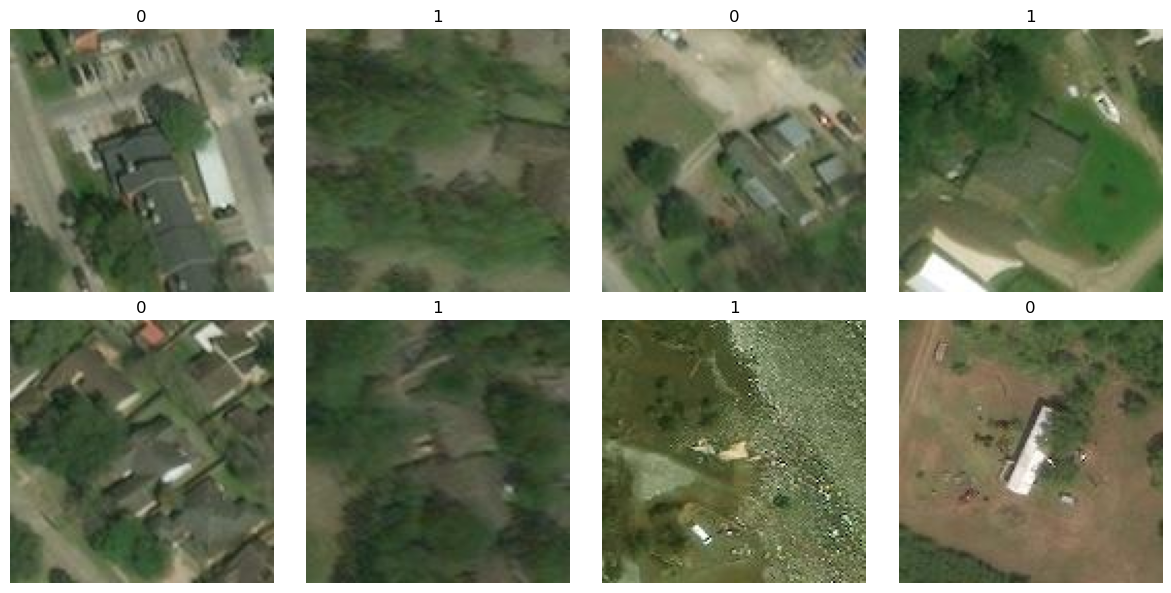

In [9]:
plt.figure(figsize=(12, 6))

for images, labels in train_ds.take(1):
    for i in range(8):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")
plt.tight_layout()

## If you want to apply data augmentation operations on the train dataset

Go to the `prepare_train_and_val_datasets(...)` and you can add augmentation operations directly to the train dataset as follows:

```
train_ds = (train_ds.map(lambda image, label: (tf.image.random_flip_left_right(image), label))
                    .map(lambda image, label: (tf.image.random_contrast(image, lower=0.2, upper=1.5), label))
                        .shuffle(2000)
                        .prefetch(buffer_size=tf.data.AUTOTUNE))
```


Remember to check [`tf.image`](https://www.tensorflow.org/api_docs/python/tf/image#image_adjustments) for various image transforms available and you can play around with augmentations

__Be careful here and don't add too many transforms which can distort the images beyond recognition__

In [10]:
train_ds = (train_ds
    .map(lambda image, label: (tf.image.random_flip_left_right(image), label))
    .map(lambda image, label: (tf.image.random_flip_up_down(image), label))
    .map(lambda image, label: (tf.image.random_contrast(image, lower=0.2, upper=1.5), label))
    .shuffle(2000)
    .prefetch(buffer_size=tf.data.AUTOTUNE))

In [11]:
base_model = tf.keras.applications.ResNet50(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SHAPE)
x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, x)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 128, 128)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 128, 128)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 128, 128)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 128, 128,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [12]:
# train
history = model.fit(train_ds, epochs=10, validation_data=val_ds)


Epoch 1/10


2026-03-20 11:16:18.726999: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - accuracy: 0.7645 - loss: 0.4905 - val_accuracy: 0.8561 - val_loss: 0.3296
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8804 - loss: 0.2954 - val_accuracy: 0.8819 - val_loss: 0.2624
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9098 - loss: 0.2390 - val_accuracy: 0.9114 - val_loss: 0.2317
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9200 - loss: 0.2107 - val_accuracy: 0.9188 - val_loss: 0.2106
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9411 - loss: 0.1708 - val_accuracy: 0.9299 - val_loss: 0.1955
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.9338 - loss: 0.1708 - val_accuracy: 0.9225 - val_loss: 0.1816
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9384 - loss: 0.1607 - val_accuracy: 0.9336 - val_loss: 0.1707
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9420 - loss: 0.1581 - val_accuracy: 0.9299 - val_loss: 0

In [13]:
# evaluate

y_true, y_pred = eval_model_on_test(model)
y_pred_binary = (y_pred > 0.5).astype(int)

print(classification_report(y_true, y_pred_binary, target_names=classes))
print(confusion_matrix(y_true, y_pred_binary))

Found 12228 files belonging to 2 classes.


Predicting on Test Data:   0%|          | 0/96 [00:00<?, ?it/s]

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step


Predicting on Test Data:   1%|          | 1/96 [00:01<02:18,  1.46s/it]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


Predicting on Test Data:  99%|█████████▉| 95/96 [00:24<00:00,  4.27it/s]

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step


Predicting on Test Data: 100%|██████████| 96/96 [00:25<00:00,  3.78it/s]

              precision    recall  f1-score   support

   no_damage       0.90      0.96      0.93      6333
      damage       0.95      0.89      0.92      5895

    accuracy                           0.92     12228
   macro avg       0.93      0.92      0.92     12228
weighted avg       0.93      0.92      0.92     12228

[[6055  278]
 [ 649 5246]]


In [16]:
# Unfreeze only the last block of ResNet50
for layer in base_model.layers:
    if layer.name.startswith("conv5") and not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

trainable = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable layers in ResNet: {trainable}/{len(base_model.layers)}")

Trainable layers in ResNet: 22/175


In [17]:
# Recompiling with lr very low
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    # Stop training if val_loss doesn't improve for 3 epochs
    # restore_best_weights ensures we keep the best model, not the last one
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    
    # If val_loss plateaus for 2 epochs, halve the learning rate to escape the plateau
    # This works as a safety net before EarlyStopping kicks in
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

In [18]:
# Fine-tuning phase: continue training from current weights (not from scratch)
# The model keeps everything learned in phase 1, now also updating conv5 block weights
# Epochs counter resets to 1 but weights are preserved from previous training
# EarlyStopping may stop before epoch 10 if val_loss stops improving
history_ft = model.fit(train_ds, epochs=10, validation_data=val_ds, callbacks=callbacks)


Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 171ms/step - accuracy: 0.9531 - loss: 0.1249 - val_accuracy: 0.9373 - val_loss: 0.1414 - learning_rate: 1.0000e-05
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.9706 - loss: 0.0752 - val_accuracy: 0.9336 - val_loss: 0.1521 - learning_rate: 1.0000e-05
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.9706 - loss: 0.0725 - val_accuracy: 0.9410 - val_loss: 0.1764 - learning_rate: 1.0000e-05
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.9853 - loss: 0.0501 - val_accuracy: 0.9373 - val_loss: 0.1413 - learning_rate: 5.0000e-06
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.9862 - loss: 0.0376 - val_accuracy: 0.9373 - val_loss: 0.1465 - learning_rate: 5.0000e-06
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.9926 - loss: 0.0315 - val_accuracy: 0.9373 - val_loss: 0.1537 - learning_rate: 2.5000e-06
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 

In [19]:
# Evaluate fine-tuned model on test set
y_true, y_pred = eval_model_on_test(model)
y_pred_binary = (y_pred > 0.5).astype(int)

print(classification_report(y_true, y_pred_binary, target_names=classes))
print(confusion_matrix(y_true, y_pred_binary))


Found 12228 files belonging to 2 classes.


Predicting on Test Data:   0%|          | 0/96 [00:00<?, ?it/s]

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


Predicting on Test Data:   1%|          | 1/96 [00:01<02:46,  1.76s/it]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


Predicting on Test Data:  99%|█████████▉| 95/96 [00:24<00:00,  4.14it/s]

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 612ms/step


Predicting on Test Data: 100%|██████████| 96/96 [00:26<00:00,  3.67it/s]

              precision    recall  f1-score   support

   no_damage       0.91      0.97      0.94      6333
      damage       0.96      0.90      0.93      5895

    accuracy                           0.93     12228
   macro avg       0.94      0.93      0.93     12228
weighted avg       0.94      0.93      0.93     12228

[[6114  219]
 [ 592 5303]]
